In [1]:
# Imports
import sys
sys.path.insert(0, 'simulation')

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

from simulation.colony import Colony, Faction, WorkerLevel, CriticalFlag, StrategicFlag, DirectiveType, Directive
from simulation.buildings import BuildingType, BuildingState, BUILDING_STATS, ResourceType
from simulation.snapshot import take_snapshot, plot_history

R = ResourceType

In [2]:
# Step 1: Create a faction and a colony
faction = Faction(faction_id=0, name="Test Faction")

colony = Colony(
    colony_id=0,
    name="Test Colony",
    system_id=0,
    population=1000.0,
    stockpile={
        int(R.MINERALS): 5000.0,
        int(R.POWER): 2000.0,
        int(R.ORGANICS): 10000.0,
        int(R.RARE_MATS): 100.0,
    },
)

faction.add_colony(colony)

print(f"Created faction: {faction.name}")
print(f"Created colony: {colony.name} with population {colony.population}")

Created faction: Test Faction
Created colony: Test Colony with population 1000.0


In [3]:
# Step 2: Establish an initial set of buildings (1 of each)
building_types = [
    BuildingType.MINE,
    BuildingType.POWER_PLANT,
    BuildingType.FARM,
    BuildingType.FACTORY,
    BuildingType.FORT,
    BuildingType.SHIPYARD,
    BuildingType.RAILYARD,
    BuildingType.LAB,
]

for bt in building_types:
    colony.construct_building(bt, planet_index=0)
    print(f"Constructed {bt.name}")

print(f"\nTotal buildings: {len(colony._buildings)}")

Constructed MINE
Constructed POWER_PLANT
Constructed FARM
Constructed FACTORY
Constructed FORT
Constructed SHIPYARD
Constructed RAILYARD
Constructed LAB

Total buildings: 8


In [4]:
# Step 3: Draft enough workers to supply those buildings
required_workers = colony.required_workers_by_level()
print(f"Required workers by level: {required_workers}")

# Recruit workers for each level
for level, count in required_workers.items():
    if level == 1:
        recruited = colony.recruit_workers(count)
    else:
        recruited = colony.recruit_workers_of_level(level, count)
    print(f"Recruited {recruited} workers at level {level}")

recruited = colony.recruit_workers(20)
print(f"Recruited {recruited} additional workers at level 1")

Required workers by level: {}
Recruited 20 additional workers at level 1


In [5]:
# Function to get net production rates (production - consumption)
def get_net_rates(colony):
    """Get net production rates for all resources."""
    from simulation.buildings import colony_production_rates, colony_production_costs
    
    produced = colony_production_rates(colony.building_counts)
    consumed = colony_production_costs(colony.building_counts)
    
    # Add population upkeep
    if R.ORGANICS not in consumed:
        consumed[R.ORGANICS] = colony.organics_upkeep_per_tick
    else:
        consumed[R.ORGANICS] += colony.organics_upkeep_per_tick
    
    all_keys = set(produced) | set(consumed)
    return {k: produced.get(k, 0.0) - consumed.get(k, 0.0) for k in all_keys}

# Function to get demand for each resource
def get_demand(colony):
    """Get consumption/demand for each resource."""
    from simulation.buildings import colony_production_costs
    
    consumed = colony_production_costs(colony.building_counts)
    
    # Add population upkeep
    consumed[R.ORGANICS] = consumed.get(R.ORGANICS, 0.0) + colony.organics_upkeep_per_tick
    
    return consumed

In [6]:
# Step 4-6: Dynamic directive system
# Start with ORGANICS focus, then progressively address lowest rates

def get_resource_priority_order(net_rates):
    """Sort resources by net rate (lowest first), excluding synthetic resources."""
    real_resources = [R.MINERALS, R.POWER, R.ORGANICS, R.RARE_MATS]
    return sorted(real_resources, key=lambda r: net_rates.get(int(r), 0.0))

def issue_directive_for_resource(colony, resource_type):
    """Issue a HARVEST directive focused on a specific resource."""
    faction.issue_directive(
        colony_id=colony.colony_id,
        directive_type=DirectiveType.HARVEST,
        tax_rate=0.10,
        urgency=1.0,
        target_resource=int(resource_type),
    )

# Step 4: Issue initial directive to focus on MINERALS
print("Initial directive: Focusing on MINERALS")
issue_directive_for_resource(colony, R.MINERALS)

# Track history for plotting
history = []

# Track which resources have been addressed
addressed_resources = set()
current_focus = R.MINERALS

Initial directive: Focusing on MINERALS


In [ ]:
# Run simulation
NUM_TICKS = 300

# building_health = np.zeros((len(colony._buildings), NUM_TICKS))

for tick in range(1, NUM_TICKS + 1):
    # Run one tick
    faction.tick()
    
    # building_health[:, tick-1] = [b.health for b in faction.colonies[0]._buildings]

    history.append(take_snapshot(faction.colonies[0]))


print(f"\nSimulation complete: {NUM_TICKS} ticks")
print(f"Final population: {colony.population:.1f}")
print(f"Final workers: {len(colony._workers)}")

======   Tick 1   ======
Colony Test Colony (id=0):  🚨 Built Farm (FOOD_SHORTAGE).
======   Tick 2   ======
Colony Test Colony (id=0):  🚨 Built Farm (FOOD_SHORTAGE).
======   Tick 3   ======
Colony Test Colony (id=0):  🚨 Built Farm (FOOD_SHORTAGE).
======   Tick 4   ======
Colony Test Colony (id=0):  🚨 Built Farm (FOOD_SHORTAGE).
======   Tick 5   ======
Colony Test Colony (id=0):  🚨 Built Farm (FOOD_SHORTAGE).
======   Tick 6   ======
Colony Test Colony (id=0):  🚨 Built Farm (FOOD_SHORTAGE).
======   Tick 7   ======
Colony Test Colony (id=0):  🚨 Built Farm (FOOD_SHORTAGE).
======   Tick 8   ======
Colony Test Colony (id=0):  FARM lv1 (id=2) construction complete.
Colony Test Colony (id=0):  👷 Assigned 5 worker(s) to FARM lv1 (id=2).
Colony Test Colony (id=0):  🚨 Built Farm (FOOD_SHORTAGE).
======   Tick 9   ======
Colony Test Colony (id=0):  FARM lv1 (id=8) construction complete.
Colony Test Colony (id=0):  👷 Assigned 5 worker(s) to FARM lv1 (id=8).
Colony Test Colony (id=0):  🚨 Built

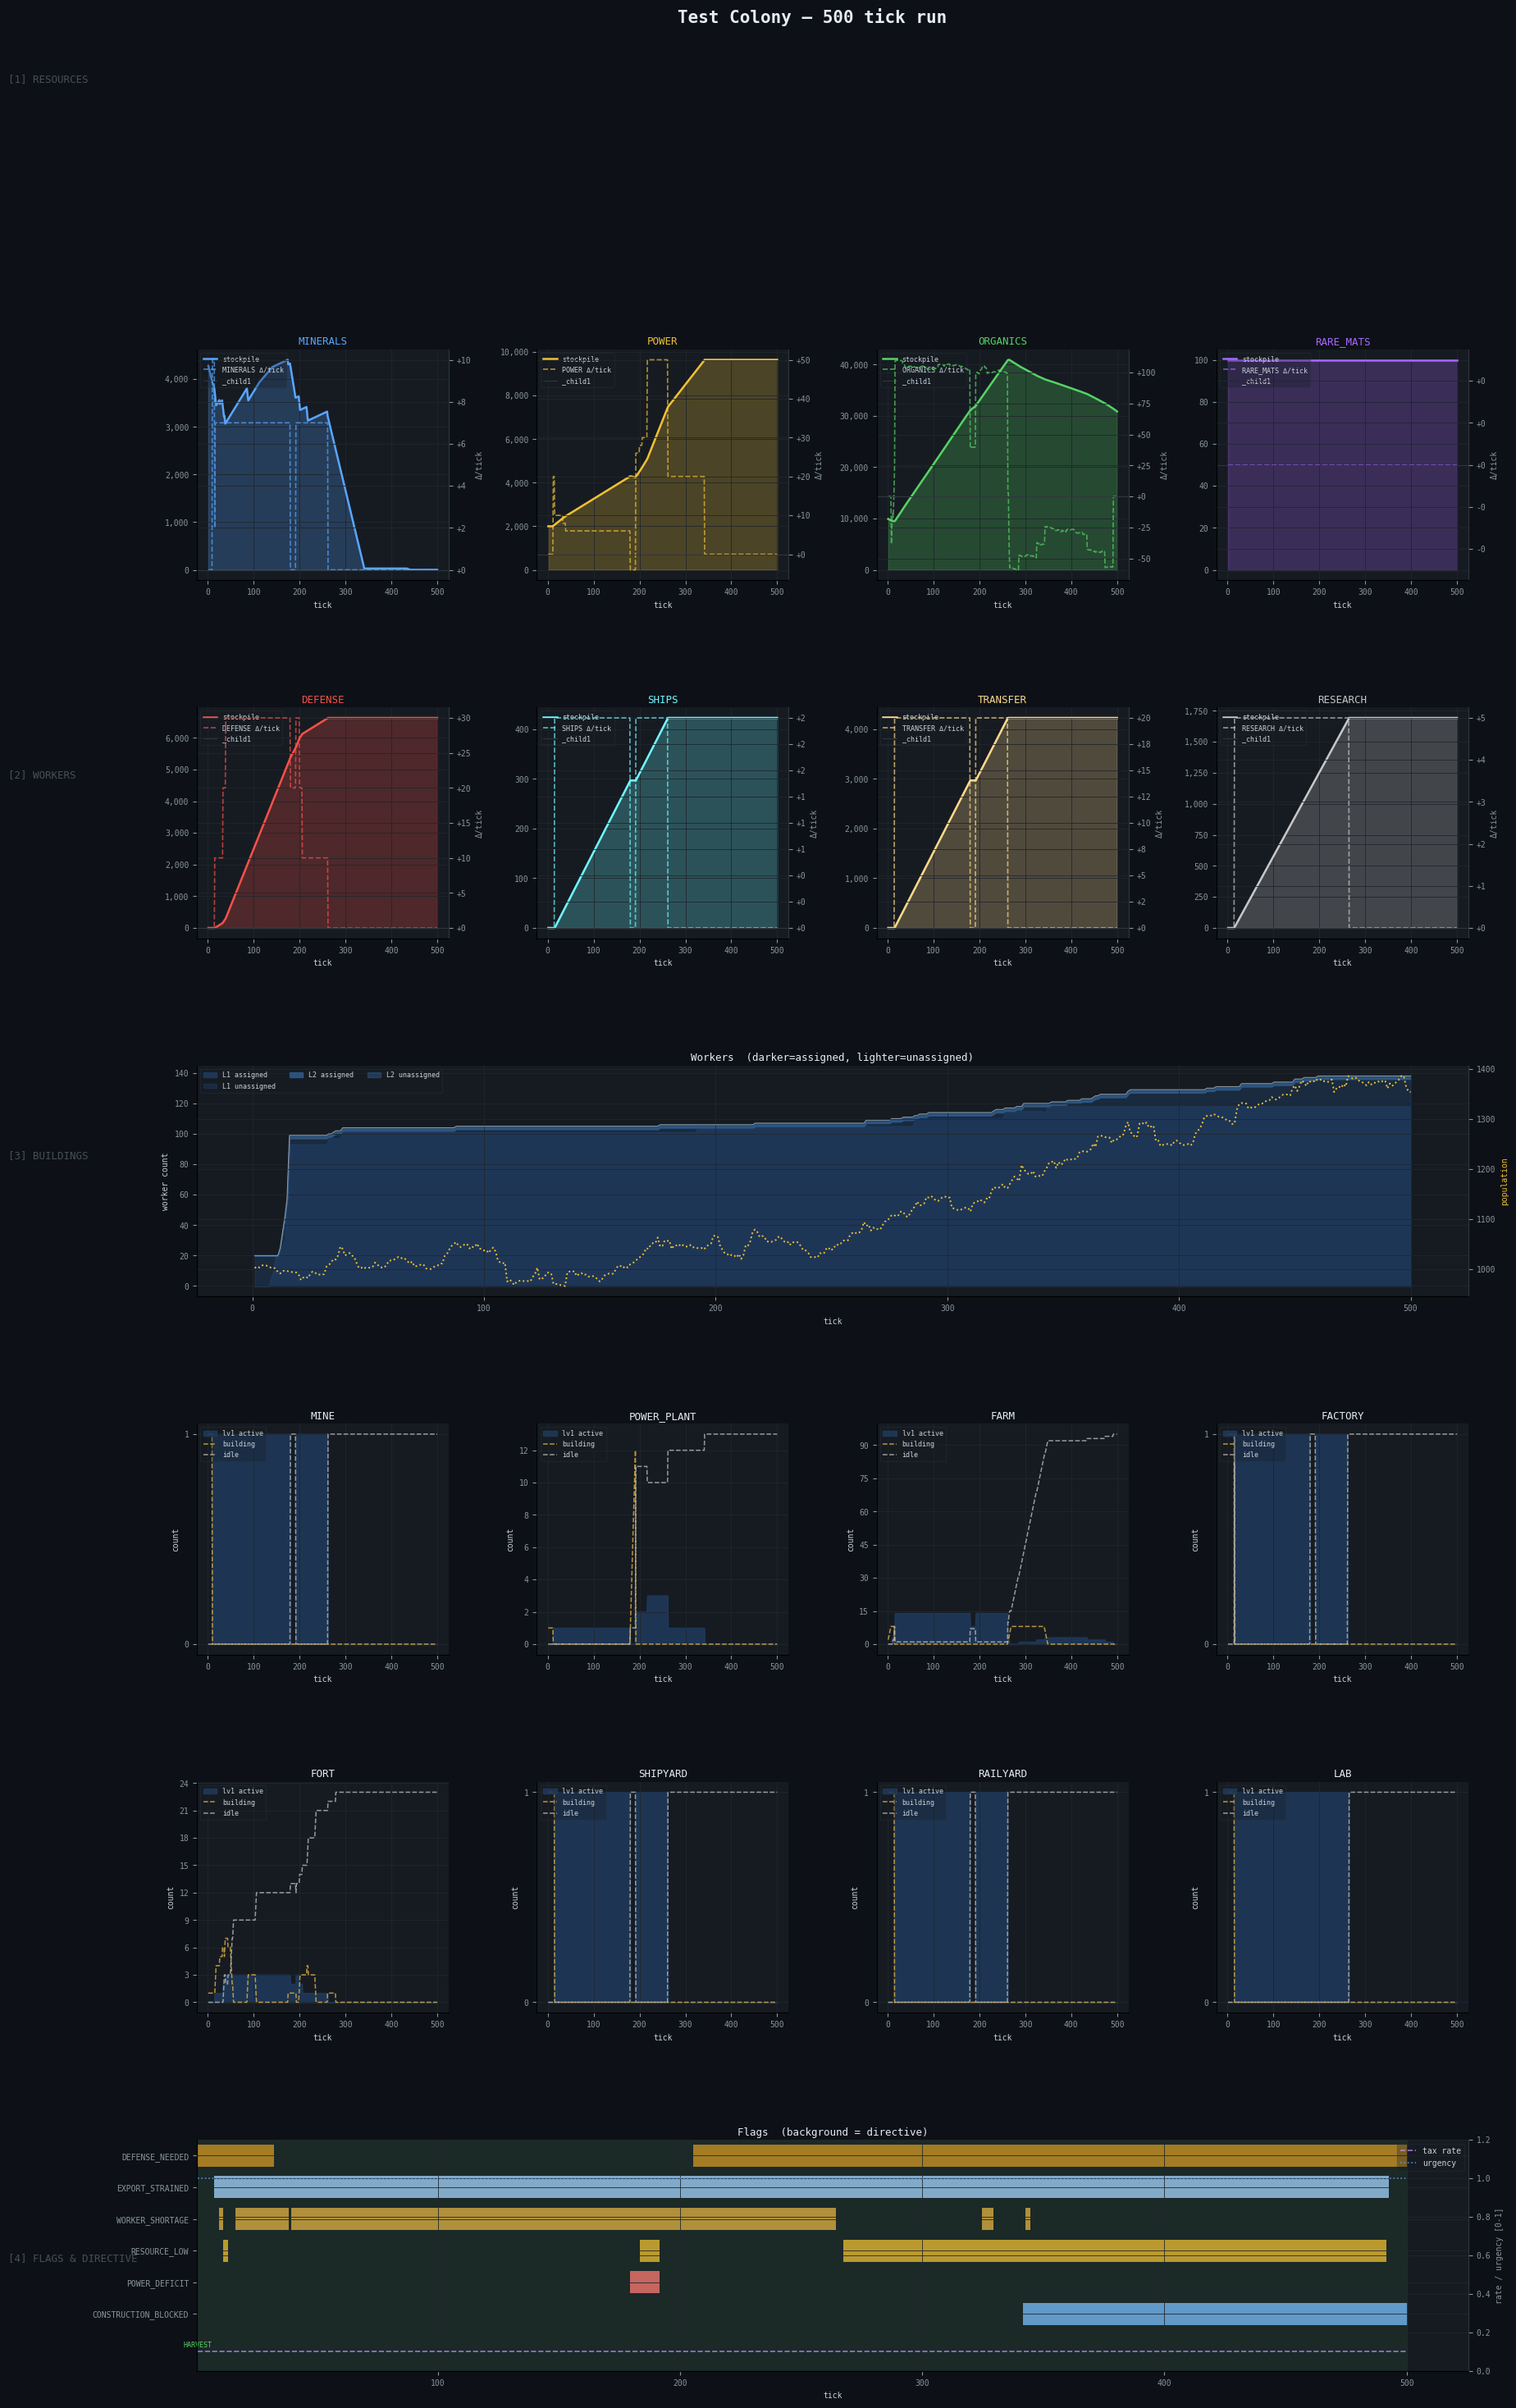

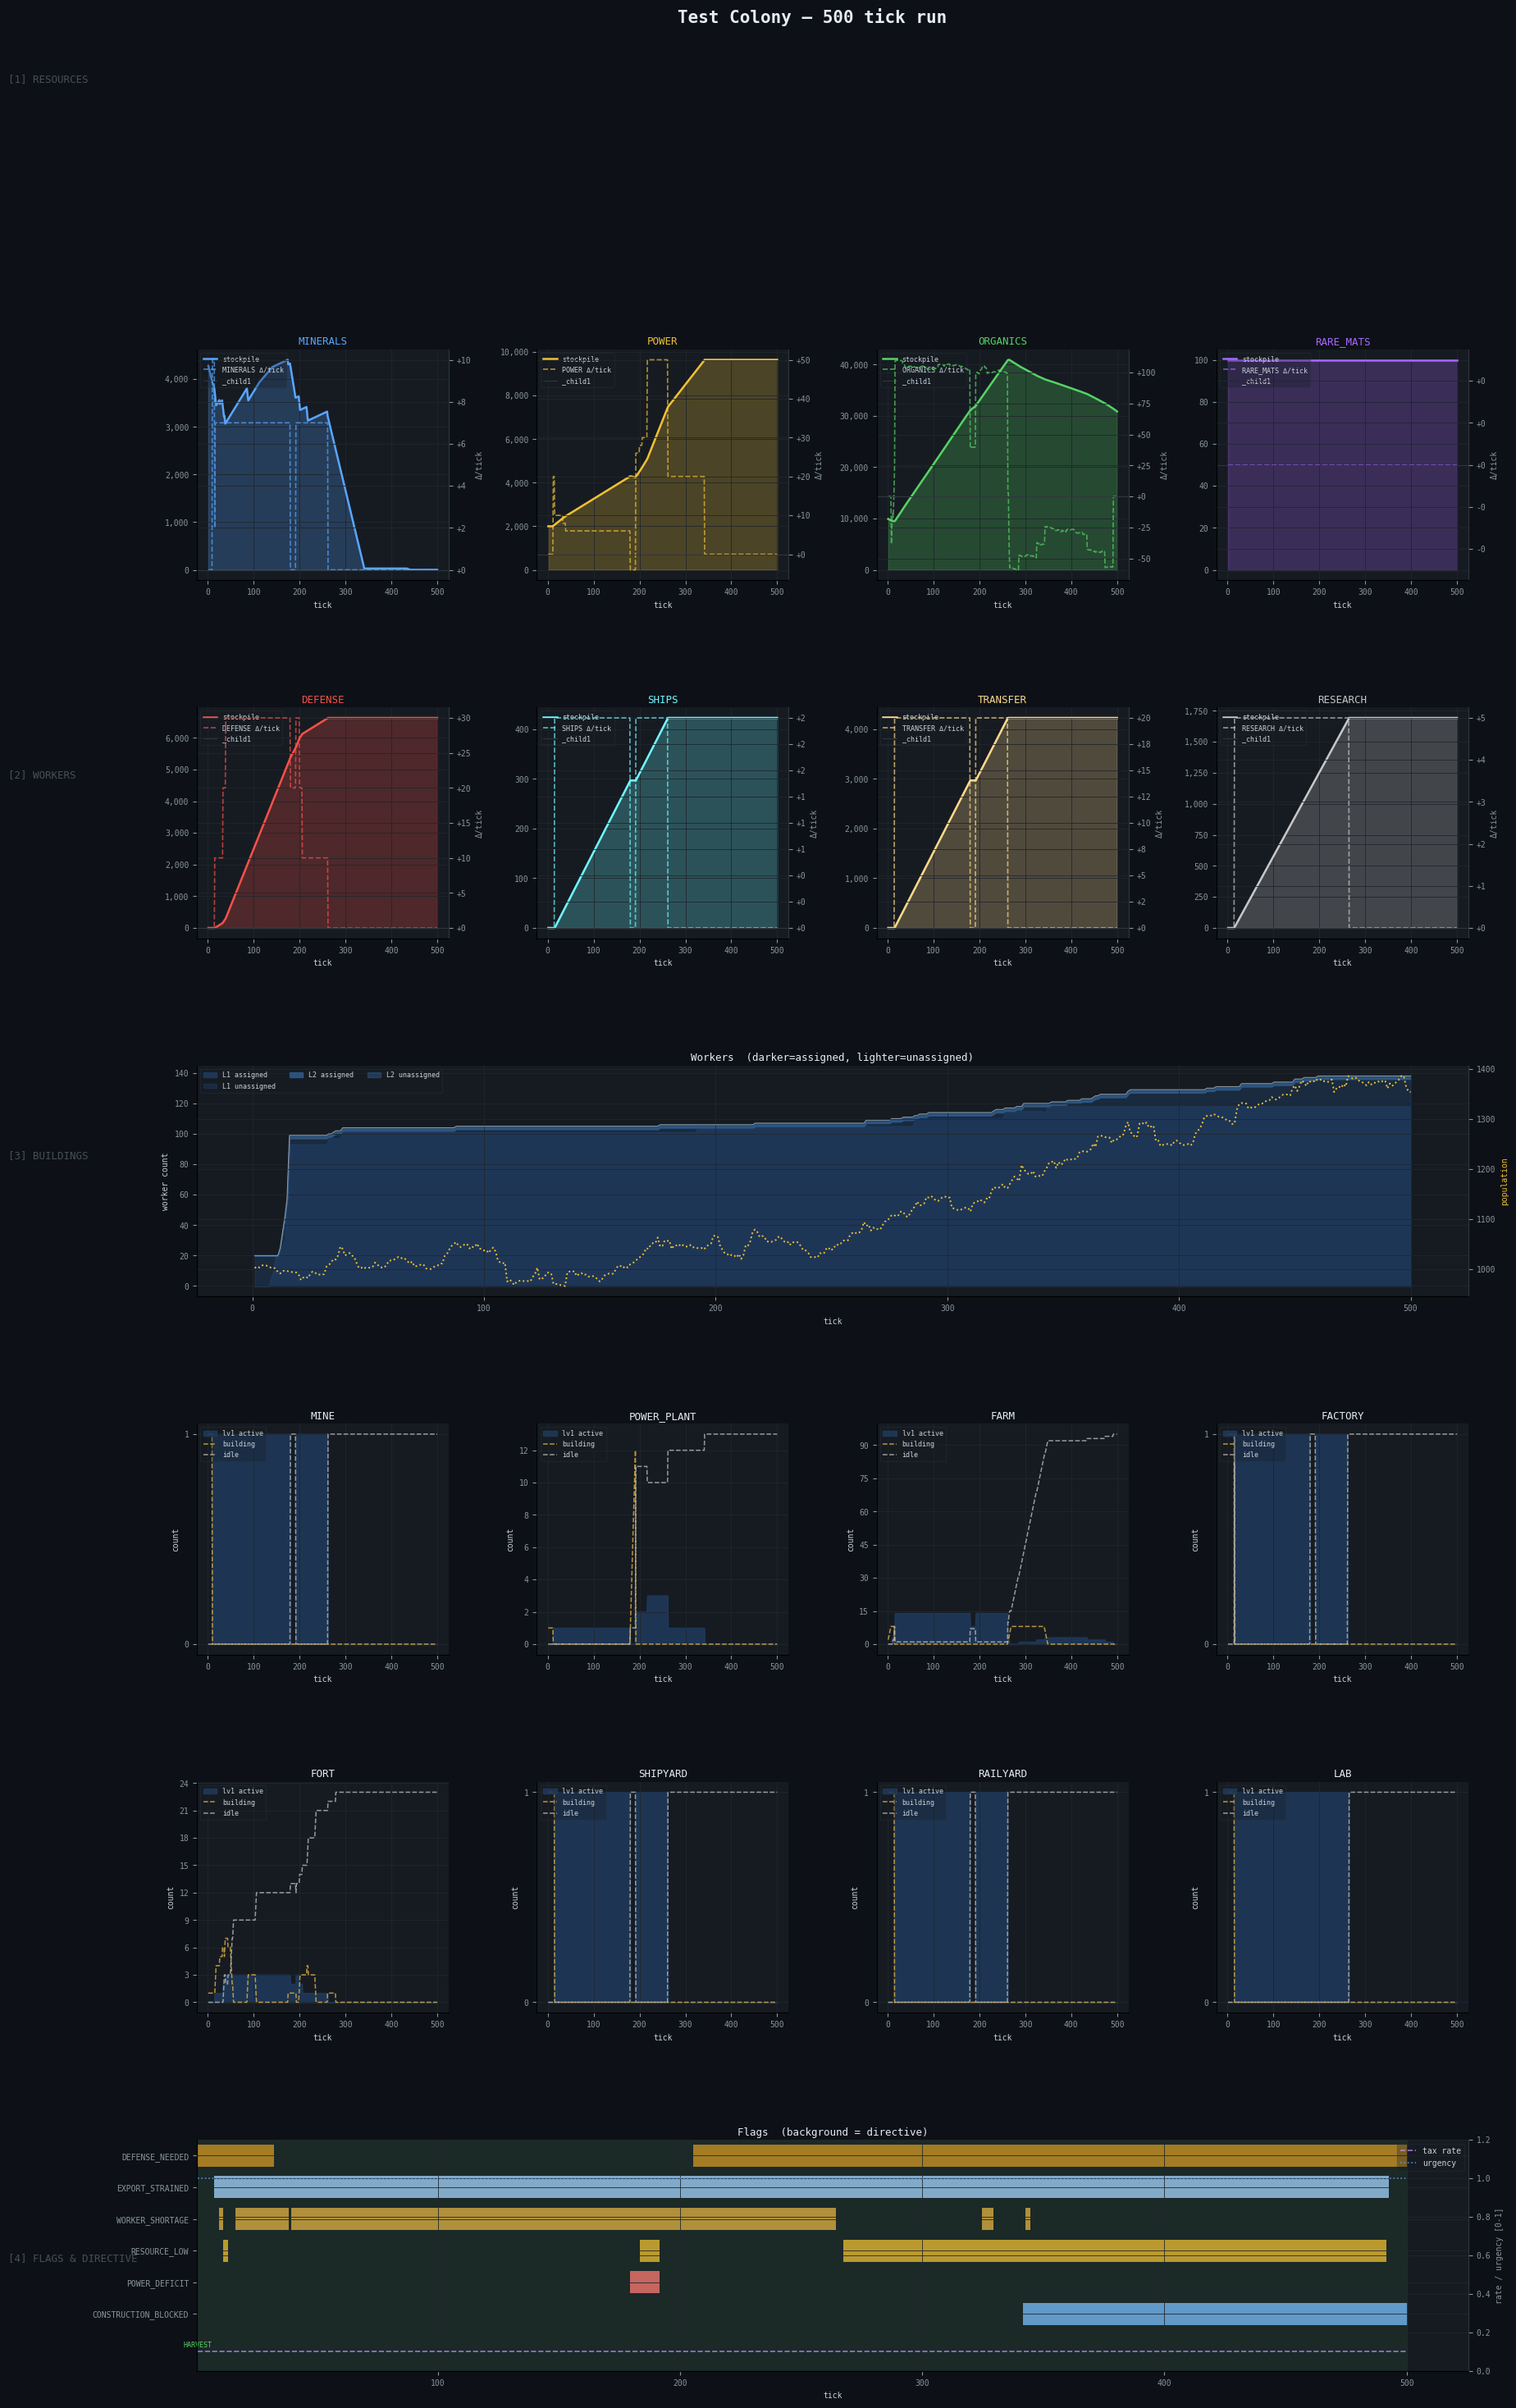

In [8]:
plot_history(history, title=f"{colony.name} — {NUM_TICKS} tick run", save_path=f"run_{NUM_TICKS}ticks.png")

In [9]:
# Print final colony state
# plt.plot(building_health[0, :],'r')
# plt.plot(building_health[0, :],'b')
# plt.xlabel('Tick')
# plt.ylabel('Health')
# plt.title('Building Health Over Time')
# plt.legend([b.building_type.name for b in colony._buildings])
# plt.grid(True)
# plt.show()